In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bisect
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

# プロジェクトルートをパスに追加
sys.path.insert(0, '/Users/nishiharahiroto/Documents/programs/market-analytics-ver1')
from data.utils.database_manager import DatabaseManager

# 定数定義
TARGET_TENORS = ['3M', '6M', '9M', '1Y', '2Y', '3Y', '5Y', '7Y']
D = 0.4
WINDOW = 50
OOS_START = '2024-01-01'

# 出力ディレクトリ
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")


In [2]:
db = DatabaseManager()

# OIS データ（product_type='OIS'）
rows = db.get_ois_data(product_type='OIS')
df_swap_raw = pd.DataFrame(rows)
df_swap_raw['trade_date'] = pd.to_datetime(df_swap_raw['trade_date'])

# ワイド形式に変換（index=trade_date, columns=tenor）
df_ois = df_swap_raw.pivot(index='trade_date', columns='tenor', values='rate')

# 7Y以下のテナーのみ残す
df_ois = df_ois[[t for t in TARGET_TENORS if t in df_ois.columns]]
df_ois = df_ois.sort_index()

# FX
fx_q = "SELECT trade_date, currency_pair, close_price FROM exchange_rates WHERE currency_pair IN ('USDJPY', 'DXY')"
df_fx = pd.DataFrame(db.select_as_dict(fx_q))
df_fx['trade_date'] = pd.to_datetime(df_fx['trade_date'])
df_fx = df_fx.pivot(index='trade_date', columns='currency_pair', values='close_price')

# 日経
nk_q = "SELECT trade_date, close_price as nikkei FROM stock_prices WHERE ticker = '^N225'"
df_nk = pd.DataFrame(db.select_as_dict(nk_q))
df_nk['trade_date'] = pd.to_datetime(df_nk['trade_date'])
df_nk = df_nk.set_index('trade_date')[['nikkei']]

# 米国10年金利
us_q = "SELECT trade_date, yield_value as ust10y FROM foreign_yields WHERE region = 'US' AND tenor = '10Y'"
df_us = pd.DataFrame(db.select_as_dict(us_q))
df_us['trade_date'] = pd.to_datetime(df_us['trade_date'])
df_us = df_us.set_index('trade_date')[['ust10y']]

# 日銀会合データ
boj_q = "SELECT meeting_date, policy_rate_after as policy_rate FROM boj_meetings ORDER BY meeting_date"
df_boj = pd.DataFrame(db.select_as_dict(boj_q))
df_boj['meeting_date'] = pd.to_datetime(df_boj['meeting_date'])
df_boj['policy_rate'] = df_boj['policy_rate'].astype(float)

# OIS + マクロを outer join で結合
df_all = df_ois.join([df_fx, df_nk, df_us], how='outer')
df_all = df_all.sort_index()

# 全行NaNは除去
df_all = df_all.dropna(how='all')

# 数値型へ
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# 補完フラグを先に立てる（補完前に必ず実行）
numeric_cols = [c for c in df_all.columns if not c.endswith('_is_imputed')]
for col in numeric_cols:
    df_all[f'{col}_is_imputed'] = df_all[col].isna().astype(int)

# MICE補完（スケーリング → 補完 → 逆スケーリング）
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_all[numeric_cols]),
    columns=numeric_cols, index=df_all.index
)
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_imputed_scaled = imputer.fit_transform(df_scaled)
df_all[numeric_cols] = scaler.inverse_transform(df_imputed_scaled)

# 日銀カレンダー特徴量
df_boj_daily = df_boj.set_index('meeting_date')[['policy_rate']]
df_boj_daily = df_boj_daily.reindex(df_all.index, method='ffill')

meeting_dates = df_boj['meeting_date'].sort_values().values
def days_to_next(date, meeting_dates):
    future = meeting_dates[meeting_dates > date]
    if len(future) == 0:
        return np.nan
    return (future[0] - date).days

df_all['policy_rate'] = df_boj_daily['policy_rate']
df_all['days_to_next_mpm'] = [days_to_next(d, meeting_dates) for d in df_all.index]

# MPM直後フラグ
df_all['is_meeting_day'] = df_all.index.isin(df_boj['meeting_date']).astype(int)
df_all['is_post_mpm'] = (
    df_all['is_meeting_day'].rolling(window=6, min_periods=1).max()
).astype(int)

print(f"OIS data range: {df_all.index.min()} to {df_all.index.max()}")


INFO:data.utils.database_manager:DatabaseManager initialized for ep-calm-boat-a1zzrjkt-pooler.ap-southeast-1.aws.neon.tech


OIS data range: 1962-01-02 00:00:00 to 2026-03-27 00:00:00


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


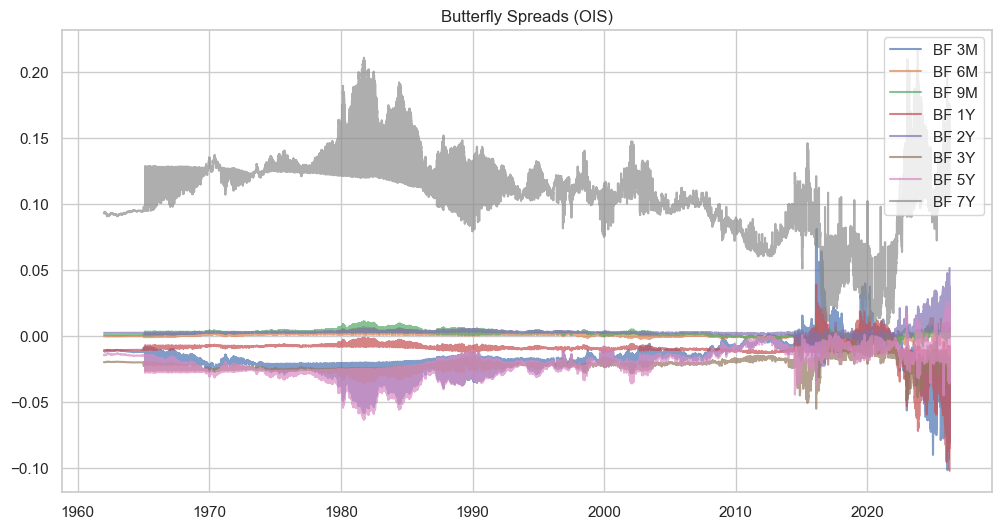

In [3]:
def compute_butterfly(df_ois: pd.DataFrame, tenor_order: list) -> pd.DataFrame:
    bf = pd.DataFrame(index=df_ois.index)
    n = len(tenor_order)
    for i, t in enumerate(tenor_order):
        if t not in df_ois.columns:
            continue
        if i == 0:
            next_t = tenor_order[i + 1]
            bf[t] = df_ois[t] - df_ois[next_t]
        elif i == n - 1:
            prev_t = tenor_order[i - 1]
            bf[t] = df_ois[t] - df_ois[prev_t]
        else:
            prev_t = tenor_order[i - 1]
            next_t = tenor_order[i + 1]
            bf[t] = df_ois[t] - 0.5 * (df_ois[prev_t] + df_ois[next_t])
    return bf

# 補完後のOIS部分を使ってバタフライ計算
df_ois_imputed = df_all[TARGET_TENORS]
df_bf = compute_butterfly(df_ois_imputed, TARGET_TENORS)

plt.figure(figsize=(12, 6))
for tenor in df_bf.columns:
    plt.plot(df_bf.index, df_bf[tenor], label=f"BF {tenor}", alpha=0.7)
plt.title("Butterfly Spreads (OIS)")
plt.legend()
plt.show()


In [4]:
def frac_diff(series: pd.Series, d: float = 0.4, window: int = 50) -> pd.Series:
    weights = [1.0]
    for k in range(1, window):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weights = np.array(weights[::-1])

    arr = series.to_numpy(dtype=float)
    n = len(arr)
    result = np.full(n, np.nan)
    if n < window:
        return pd.Series(result, index=series.index)

    from numpy.lib.stride_tricks import sliding_window_view
    windows_view = sliding_window_view(arr, window_shape=window)
    dots = windows_view @ weights
    dots[np.isnan(windows_view).any(axis=1)] = np.nan
    result[window - 1:] = dots
    return pd.Series(result, index=series.index)

def tenor_to_float(t: str) -> float:
    num = float(''.join(filter(str.isdigit, t)))
    return num / 12.0 if 'M' in t else num

def build_pooled_df(
    df_all: pd.DataFrame,
    df_bf: pd.DataFrame,
    ois_cols: list,
    macro_cols: list,
    h: int,
    config: str,
) -> pd.DataFrame:
    macro_fd = {f'{m}_fd': frac_diff(df_all[m], D, WINDOW)
                for m in macro_cols if m in df_all.columns}

    bf_fd_dict = {}
    for t in ois_cols:
        if t in df_bf.columns:
            bf_fd_dict[t] = frac_diff(df_bf[t], D, WINDOW)

    all_rows = []
    for tenor in ois_cols:
        s    = df_all[tenor]
        bf_s = df_bf.get(tenor, None)

        target = s.shift(-h) - s

        if config == 'A':
            row_data = {
                'ois_level':    s,
                'ois_spread_h': s - s.shift(h),
                'ois_fd':       frac_diff(s, D, WINDOW),
            }
        elif config == 'B':
            # Config A の全特徴量をベースに、全テナーのBF水準とFDを追加
            row_data = {
                'ois_level':    s,
                'ois_spread_h': s - s.shift(h),
                'ois_fd':       frac_diff(s, D, WINDOW),
            }
            for t in ois_cols:
                if t in df_bf.columns:
                    row_data[f'bf_all_{t}']    = df_bf[t]
                    row_data[f'bf_all_{t}_fd'] = bf_fd_dict.get(t, pd.Series(np.nan, index=df_all.index))
        elif config == 'C':
            row_data = {
                'ois_level':        s,
                'ois_spread_h':     s - s.shift(h),
                'ois_fd':           frac_diff(s, D, WINDOW),
                'bf_target_level':  bf_s if bf_s is not None else np.nan,
                'bf_target_fd':     bf_fd_dict.get(tenor, pd.Series(np.nan, index=df_all.index)),
            }

        tmp = pd.DataFrame({
            'tenor':            tenor,
            'tenor_val':        tenor_to_float(tenor),
            **row_data,
            'policy_rate':      df_all.get('policy_rate',       pd.Series(np.nan, index=df_all.index)),
            'days_to_next_mpm': df_all.get('days_to_next_mpm',  pd.Series(np.nan, index=df_all.index)),
            'is_post_mpm':      df_all['is_post_mpm'],
            'target':           target,
        }, index=df_all.index)

        for col, fd_series in macro_fd.items():
            tmp[col] = fd_series

        for flag_col in [c for c in df_all.columns if c.endswith('_is_imputed')]:
            tmp[flag_col] = df_all[flag_col]

        all_rows.append(tmp)

    df_long = pd.concat(all_rows).sort_index()
    feat_cols = [c for c in df_long.columns if c not in ('tenor', 'is_post_mpm', 'target')]
    df_long = df_long.dropna(subset=feat_cols + ['target'])
    df_long = df_long[df_long['is_post_mpm'] == 0].drop(columns='is_post_mpm')

    df_long['target_std']  = df_long.groupby('tenor')['target'].transform('std')
    df_long['target_norm'] = df_long['target'] / df_long['target_std']

    return df_long

In [5]:
PARAMS = {
    'objective':       'regression',
    'metric':          'rmse',
    'verbosity':       -1,
    'boosting_type':   'gbdt',
    'random_state':    42,
    'learning_rate':   0.05,
    'num_leaves':      31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_data_in_leaf': 30,
    'lambda_l2':       1.0,
}
NUM_BOOST_ROUND = 100
TEST_WINDOW_DAYS = 90
PURGE_DAYS = 5

NON_FEATURE_COLS = {'tenor', 'target', 'target_std', 'target_norm'}

def walk_forward(df_long: pd.DataFrame, oos_start: str) -> pd.DataFrame:
    target_col  = 'target_norm'
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]

    unique_dates = sorted(df_long.index.unique())
    oos_start_dt = pd.to_datetime(oos_start)
    start_idx = bisect.bisect_left(unique_dates, oos_start_dt)

    results = []
    current_idx = start_idx
    fold = 0

    while current_idx < len(unique_dates):
        train_end  = unique_dates[current_idx - 1]
        purge_end  = train_end - pd.Timedelta(days=PURGE_DAYS)
        test_start = unique_dates[current_idx]
        test_end   = test_start + pd.Timedelta(days=TEST_WINDOW_DAYS)

        train_mask = df_long.index <= purge_end
        test_mask  = (df_long.index >= test_start) & (df_long.index < test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 10:
            current_idx = bisect.bisect_left(unique_dates, test_end)
            continue

        X_train = df_long.loc[train_mask, feature_cols]
        y_train = df_long.loc[train_mask, target_col]
        X_test  = df_long.loc[test_mask,  feature_cols]
        y_test  = df_long.loc[test_mask,  target_col]

        dtrain = lgb.Dataset(X_train, label=y_train)
        model  = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)

        preds      = model.predict(X_test)
        train_ic, _ = spearmanr(y_train, model.predict(X_train))

        fold_df = df_long.loc[test_mask, ['tenor', 'target', 'target_std']].copy()
        fold_df['pred_norm'] = preds
        fold_df['pred']      = preds * fold_df['target_std']
        fold_df['actual']    = fold_df['target']
        fold_df['fold']      = fold
        fold_df['train_ic']  = train_ic

        results.append(fold_df)

        fold += 1
        current_idx = bisect.bisect_left(unique_dates, test_end)

    return pd.concat(results).reset_index(names='date') if results else pd.DataFrame()

def summarize_ic(results_df: pd.DataFrame, recent_n_folds: int = 3) -> dict:
    if results_df.empty: return {}
    actual = results_df['actual']
    pred   = results_df['pred_norm']

    ic_all, _ = spearmanr(actual, pred)

    cs_ics = []
    for date, grp in results_df.groupby('date'):
        if len(grp) >= 3:
            ic, _ = spearmanr(grp['actual'], grp['pred_norm'])
            if not np.isnan(ic):
                cs_ics.append(ic)
    cs_ic = np.mean(cs_ics) if cs_ics else np.nan

    ts_ics = []
    for tenor, grp in results_df.groupby('tenor'):
        if len(grp) >= 5:
            ic, _ = spearmanr(grp['actual'], grp['pred_norm'])
            if not np.isnan(ic):
                ts_ics.append(ic)
    ts_ic = np.mean(ts_ics) if ts_ics else np.nan

    unique_folds = sorted(results_df['fold'].unique())
    recent_folds = unique_folds[-recent_n_folds:]
    recent_df    = results_df[results_df['fold'].isin(recent_folds)]
    ic_recent, _ = spearmanr(recent_df['actual'], recent_df['pred_norm'])

    train_ic = results_df.groupby('fold')['train_ic'].first().mean()
    gap      = train_ic - ic_all

    return dict(
        ic_all=ic_all, ic_recent=ic_recent,
        cs_ic=cs_ic, ts_ic=ts_ic,
        train_ic=train_ic, gap=gap,
    )


In [6]:
MACRO_COLS = ['USDJPY', 'DXY', 'nikkei', 'ust10y']
OIS_COLS = TARGET_TENORS
results = {}
walk_results = {}

for config in ['A', 'B', 'C']:
    print(f"Running Config {config}...")
    df_long_3d = build_pooled_df(df_all, df_bf, OIS_COLS, MACRO_COLS, h=3, config=config)
    df_long_5d = build_pooled_df(df_all, df_bf, OIS_COLS, MACRO_COLS, h=5, config=config)

    res_3d = walk_forward(df_long_3d, OOS_START)
    res_5d = walk_forward(df_long_5d, OOS_START)

    walk_results[(config, 3)] = res_3d
    walk_results[(config, 5)] = res_5d
    results[(config, 3)] = summarize_ic(res_3d)
    results[(config, 5)] = summarize_ic(res_5d)
    print(f"Config {config} done.")


Running Config A...


Config A done.
Running Config B...


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_9830/2681776821.py:81: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(grp['actual'], grp['pred_norm'])
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_9830/2681776821.py:81: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(grp['actual'], grp['pred_norm'])


Config B done.
Running Config C...


Config C done.


In [7]:
rows = []
for (config, h), stats in results.items():
    rows.append({
        'Config': config,
        'h': h,
        'Global IC': round(stats.get('ic_all',    np.nan), 3),
        'CS IC':     round(stats.get('cs_ic',     np.nan), 3),
        'TS IC':     round(stats.get('ts_ic',     np.nan), 3),
        'Gap':       round(stats.get('gap',       np.nan), 3),
        'ic_recent': round(stats.get('ic_recent', np.nan), 3),
    })

df_comparison = pd.DataFrame(rows).set_index(['Config', 'h'])
display(df_comparison)


Global IC  CS IC  TS IC    Gap  ic_recent
Config h                                           
A      3      0.193  0.010  0.200  0.093      0.162
       5      0.152 -0.022  0.165  0.191      0.158
B      3      0.162 -0.032  0.171  0.220      0.202
       5      0.200  0.049  0.204  0.233      0.375
C      3      0.182  0.030  0.193  0.102      0.153
       5      0.139  0.014  0.152  0.205      0.148

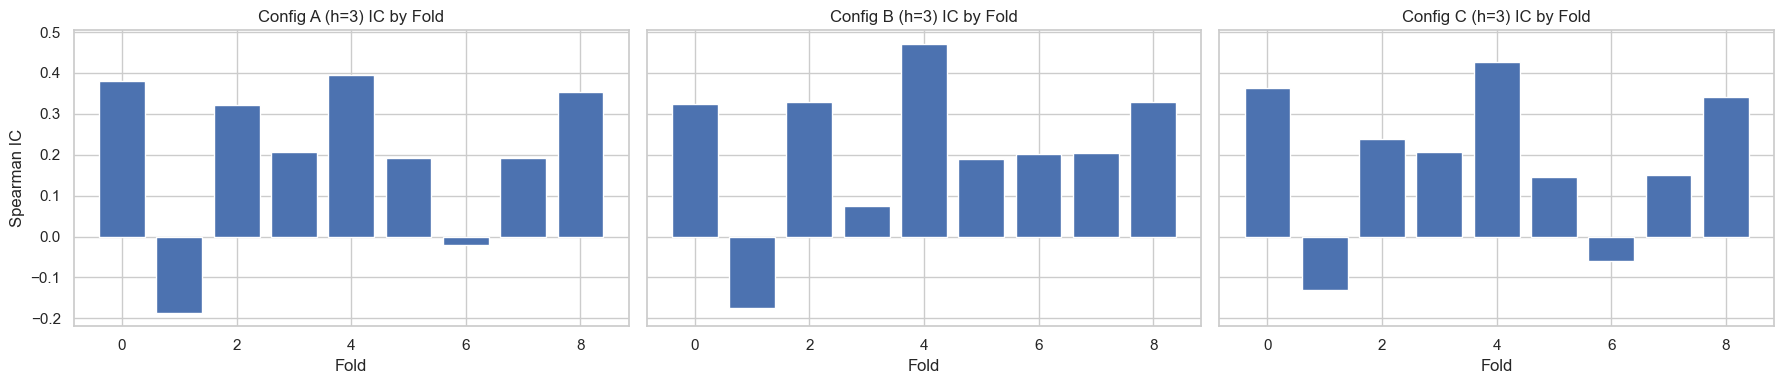

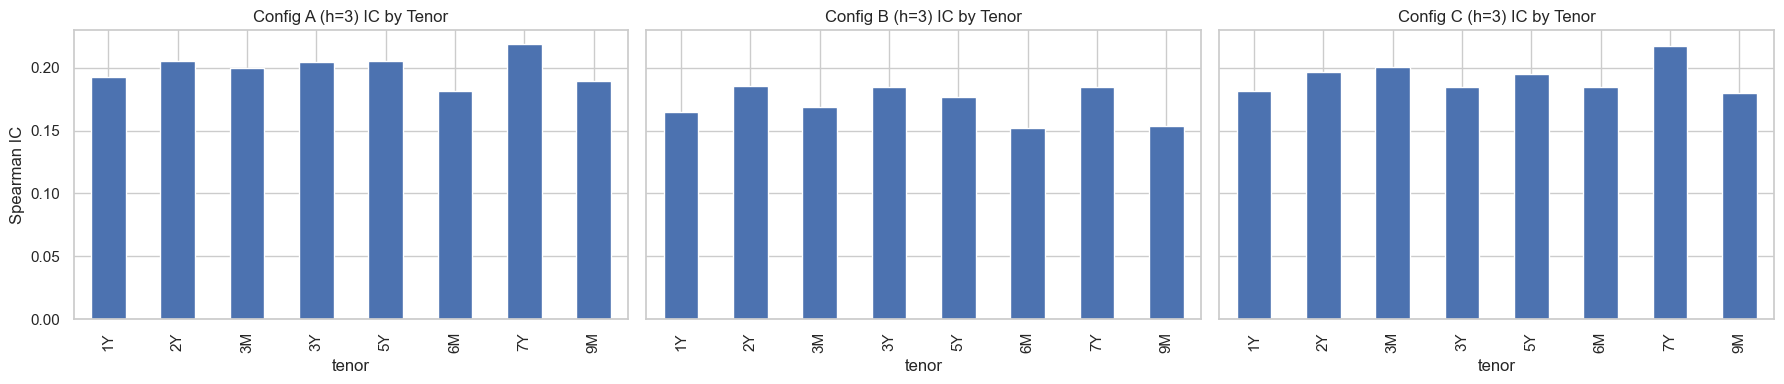

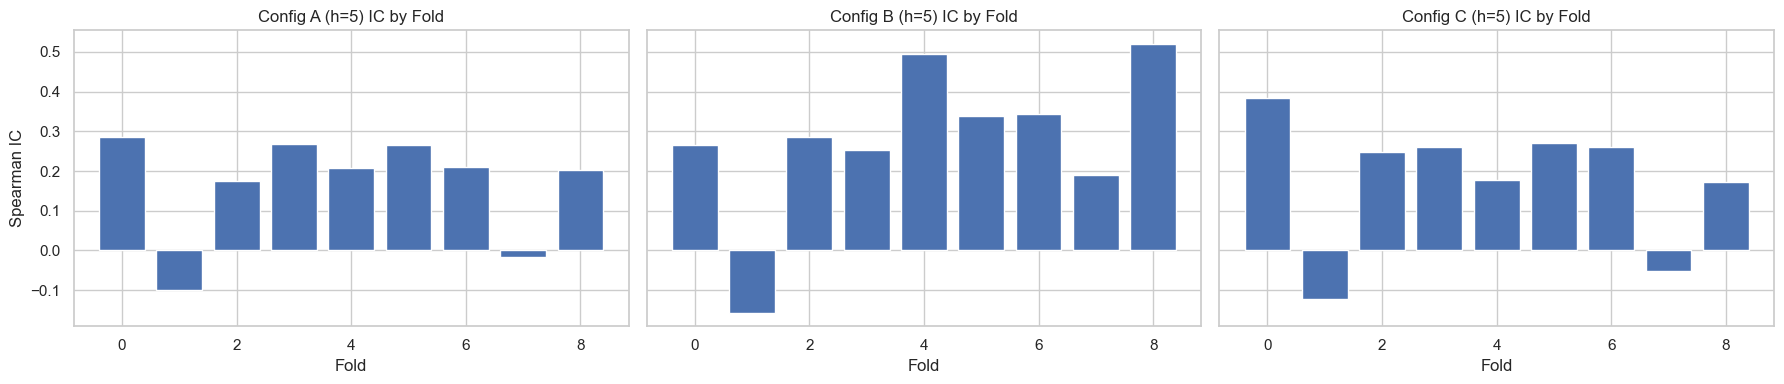

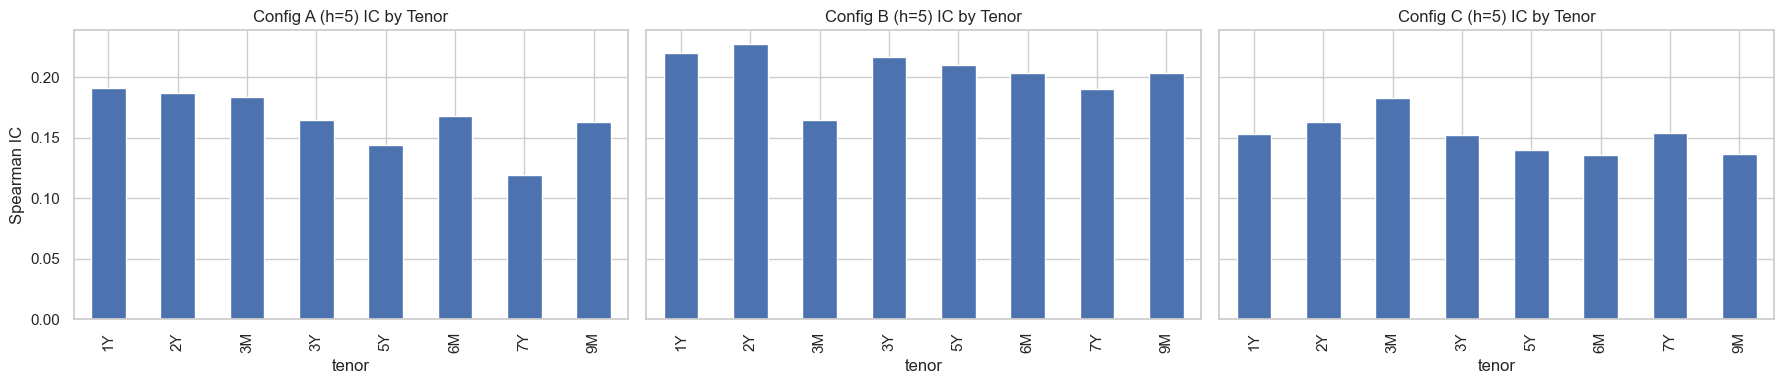

In [8]:
for h in [3, 5]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    for ax, config in zip(axes, ['A', 'B', 'C']):
        res = walk_results[(config, h)]
        if res.empty: continue
        fold_ics = [spearmanr(g['actual'], g['pred_norm'])[0]
                    for _, g in res.groupby('fold')]
        ax.bar(range(len(fold_ics)), fold_ics)
        ax.set_title(f"Config {config} (h={h}) IC by Fold")
        ax.set_xlabel("Fold")
    axes[0].set_ylabel("Spearman IC")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    for ax, config in zip(axes, ['A', 'B', 'C']):
        res = walk_results[(config, h)]
        if res.empty: continue
        tenor_ics = res.groupby('tenor').apply(lambda x: spearmanr(x['actual'], x['pred_norm'])[0], include_groups=False)
        tenor_ics.plot(kind='bar', ax=ax)
        ax.set_title(f"Config {config} (h={h}) IC by Tenor")
    axes[0].set_ylabel("Spearman IC")
    plt.tight_layout()
    plt.show()


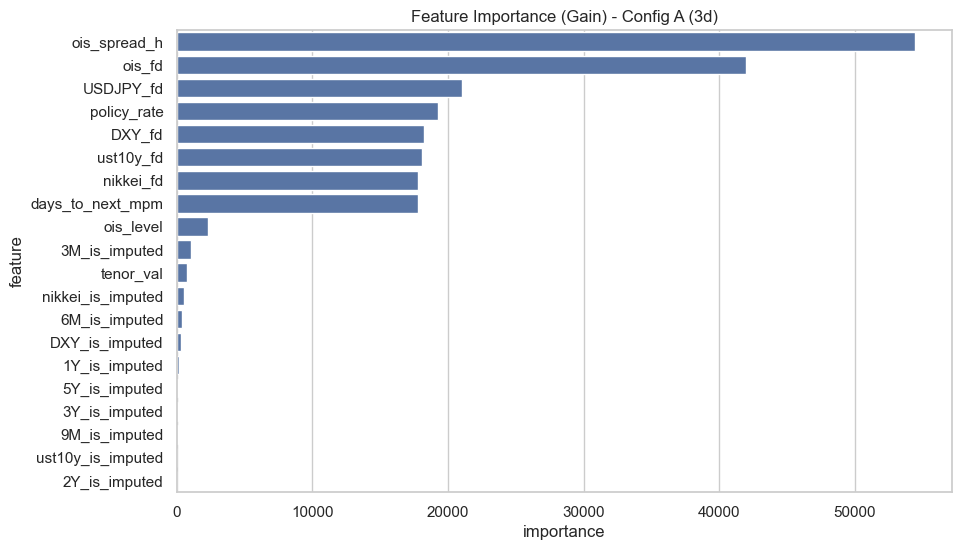

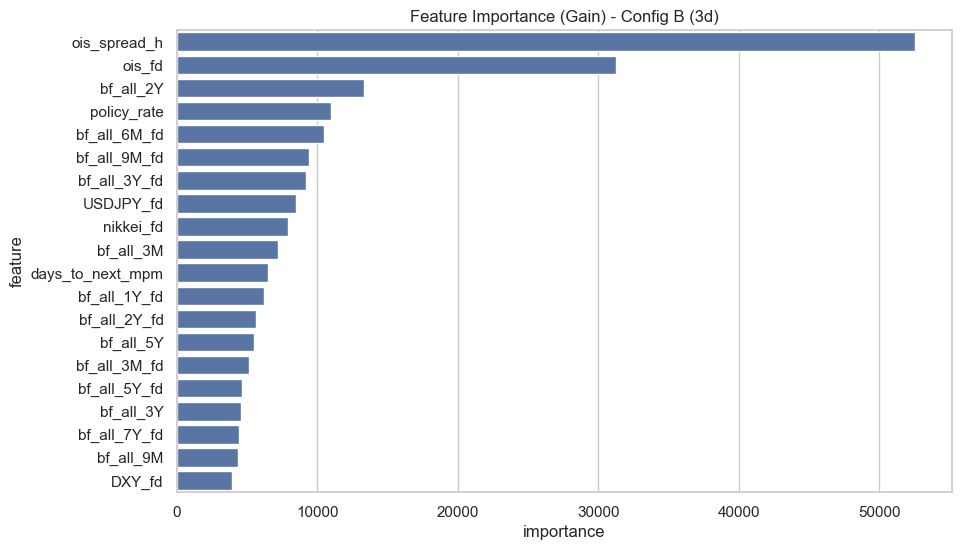

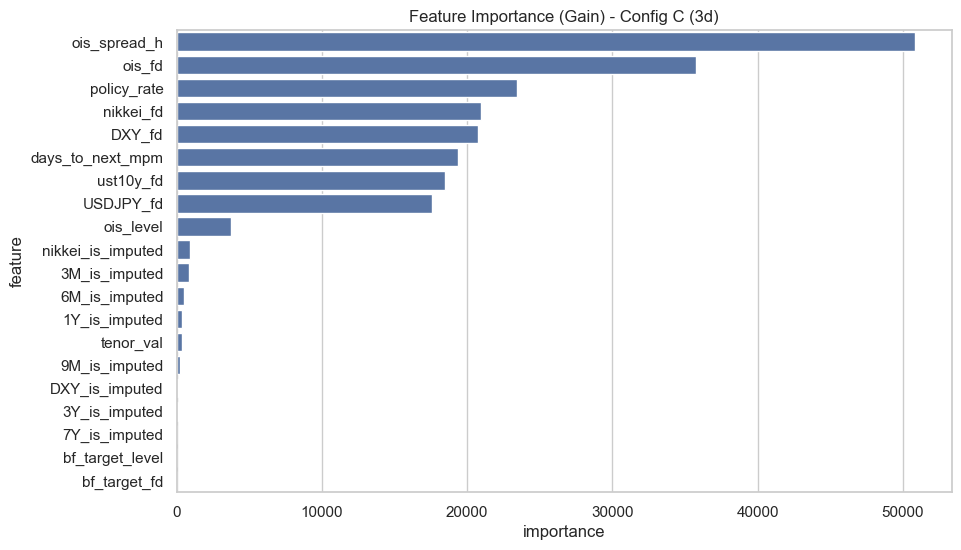

In [9]:
def plot_importance_full(df_all, df_bf, ois_cols, macro_cols, config, h_str):
    df_long = build_pooled_df(df_all, df_bf, ois_cols, macro_cols, h=3 if h_str=='3d' else 5, config=config)
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]
    X = df_long[feature_cols]
    y = df_long['target_norm']
    
    dtrain = lgb.Dataset(X, label=y)
    model = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)
    
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance.head(20), x='importance', y='feature')
    plt.title(f"Feature Importance (Gain) - Config {config} ({h_str})")
    plt.show()

for config in ['A', 'B', 'C']:
    plot_importance_full(df_all, df_bf, OIS_COLS, MACRO_COLS, config, '3d')


In [10]:
# Results Summary
# (Note: Values will be populated after execution)
summary_template = """
実験名: spot_rate_7y_compare
対象テナー: 3M, 6M, 9M, 1Y, 2Y, 3Y, 5Y, 7Y
OOS開始日: 2024-01-01
rounds: 100

--- h=3 ---
Config A: Global IC={results[('A', 3)].get('ic_all',0):.3f}, CS IC={results[('A', 3)].get('cs_ic',0):.3f}, TS IC={results[('A', 3)].get('ts_ic',0):.3f}, Gap={results[('A', 3)].get('gap',0):.3f}
Config B: Global IC={results[('B', 3)].get('ic_all',0):.3f}, CS IC={results[('B', 3)].get('cs_ic',0):.3f}, TS IC={results[('B', 3)].get('ts_ic',0):.3f}, Gap={results[('B', 3)].get('gap',0):.3f}
Config C: Global IC={results[('C', 3)].get('ic_all',0):.3f}, CS IC={results[('C', 3)].get('cs_ic',0):.3f}, TS IC={results[('C', 3)].get('ts_ic',0):.3f}, Gap={results[('C', 3)].get('gap',0):.3f}

--- h=5 ---
Config A: Global IC={results[('A', 5)].get('ic_all',0):.3f}, CS IC={results[('A', 5)].get('cs_ic',0):.3f}, TS IC={results[('A', 5)].get('ts_ic',0):.3f}, Gap={results[('A', 5)].get('gap',0):.3f}
Config B: Global IC={results[('B', 5)].get('ic_all',0):.3f}, CS IC={results[('B', 5)].get('cs_ic',0):.3f}, TS IC={results[('B', 5)].get('ts_ic',0):.3f}, Gap={results[('B', 5)].get('gap',0):.3f}
Config C: Global IC={results[('C', 5)].get('ic_all',0):.3f}, CS IC={results[('C', 5)].get('cs_ic',0):.3f}, TS IC={results[('C', 5)].get('ts_ic',0):.3f}, Gap={results[('C', 5)].get('gap',0):.3f}

採用: （CS ICで最も改善したConfigを記載）
特記事項:
- 
"""
print(summary_template)



実験名: spot_rate_7y_compare
対象テナー: 3M, 6M, 9M, 1Y, 2Y, 3Y, 5Y, 7Y
OOS開始日: 2024-01-01
rounds: 100

--- h=3 ---
Config A: Global IC={results[('A', 3)].get('ic_all',0):.3f}, CS IC={results[('A', 3)].get('cs_ic',0):.3f}, TS IC={results[('A', 3)].get('ts_ic',0):.3f}, Gap={results[('A', 3)].get('gap',0):.3f}
Config B: Global IC={results[('B', 3)].get('ic_all',0):.3f}, CS IC={results[('B', 3)].get('cs_ic',0):.3f}, TS IC={results[('B', 3)].get('ts_ic',0):.3f}, Gap={results[('B', 3)].get('gap',0):.3f}
Config C: Global IC={results[('C', 3)].get('ic_all',0):.3f}, CS IC={results[('C', 3)].get('cs_ic',0):.3f}, TS IC={results[('C', 3)].get('ts_ic',0):.3f}, Gap={results[('C', 3)].get('gap',0):.3f}

--- h=5 ---
Config A: Global IC={results[('A', 5)].get('ic_all',0):.3f}, CS IC={results[('A', 5)].get('cs_ic',0):.3f}, TS IC={results[('A', 5)].get('ts_ic',0):.3f}, Gap={results[('A', 5)].get('gap',0):.3f}
Config B: Global IC={results[('B', 5)].get('ic_all',0):.3f}, CS IC={results[('B', 5)].get('cs_ic',0):.